# 03 Modeling Gas Usage (Cyclical + Property-Type Interactions)

## 1) Load the cleaned gas usage dataset

Data source: `data/clean/gas_monthly_usage_original_categories.csv`


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 50)

gas_path = "../../data/clean/gas_monthly_usage_original_categories.csv"
df = pd.read_csv(gas_path)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 8,412
Columns: 6


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Drinking Water Treatment & Distribution,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Drinking Water Treatment & Distribution,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Drinking Water Treatment & Distribution,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Drinking Water Treatment & Distribution,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Drinking Water Treatment & Distribution,325447,2024-05-01,7784.48


## 2) Remove invalid rows and keep required columns

Rules:
- Remove rows where `Gross Floor Area == 1`
- Keep:
  - `Portfolio Manager ID` (property id)
  - `Property Type - Self-Selected`
  - `Gross Floor Area`
  - `month`
  - `normalized_monthly_usage`


In [2]:
required_columns = [
    "Portfolio Manager ID",
    "Property Type - Self-Selected",
    "Gross Floor Area",
    "month",
    "normalized_monthly_usage",
]

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_model = df[required_columns].copy()
df_model = df_model.rename(columns={"Portfolio Manager ID": "property_id"})

rows_before = len(df_model)

df_model["property_id"] = df_model["property_id"].astype("string").str.strip()
df_model["Property Type - Self-Selected"] = (
    df_model["Property Type - Self-Selected"].astype("string").str.strip()
)
df_model["Gross Floor Area"] = pd.to_numeric(df_model["Gross Floor Area"], errors="coerce")
df_model["normalized_monthly_usage"] = pd.to_numeric(df_model["normalized_monthly_usage"], errors="coerce")
df_model["month"] = pd.to_datetime(df_model["month"], errors="coerce")

df_model = df_model[df_model["Gross Floor Area"] != 1].copy()

valid_mask = (
    df_model["property_id"].notna()
    & df_model["property_id"].ne("")
    & df_model["Property Type - Self-Selected"].notna()
    & df_model["Property Type - Self-Selected"].ne("")
    & df_model["Gross Floor Area"].notna()
    & df_model["month"].notna()
    & df_model["normalized_monthly_usage"].notna()
)

df_model = df_model.loc[valid_mask].copy()
df_model["month_num"] = df_model["month"].dt.month
df_model["month"] = pd.Categorical(
    df_model["month"].dt.strftime("%b"),
    categories=MONTH_ORDER,
    ordered=True,
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {len(df_model):,}")
print(f"Rows removed: {rows_before - len(df_model):,}")
print(f"Unique properties: {df_model['property_id'].nunique():,}")
df_model.head()

Rows before cleaning: 8,412
Rows after cleaning: 8,052
Rows removed: 360
Unique properties: 671


,property_id,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage,month_num
0,35000838,Drinking Water Treatment & Distribution,325447,Jan,23839.31,1
1,35000838,Drinking Water Treatment & Distribution,325447,Feb,18735.80,2
2,35000838,Drinking Water Treatment & Distribution,325447,Mar,14082.81,3
3,35000838,Drinking Water Treatment & Distribution,325447,Apr,11537.50,4
4,35000838,Drinking Water Treatment & Distribution,325447,May,7784.48,5


## 3) Remove outliers

Outlier removal strategy (aligned with `03-modeling.ipynb`):
1. Remove the top 1% of properties by average `normalized_monthly_usage`.
2. From the remaining rows, remove the top 1% rows by `Gross Floor Area`.


In [3]:
# 3.1 Remove top 1% properties by average normalized monthly usage
property_avg_usage = (
    df_model.groupby("property_id", as_index=False)["normalized_monthly_usage"]
    .mean()
    .rename(columns={"normalized_monthly_usage": "avg_normalized_monthly_usage"})
)

property_count = len(property_avg_usage)
usage_outlier_property_count = max(1, int(np.ceil(property_count * 0.01))) if property_count > 0 else 0

usage_outlier_property_ids = (
    property_avg_usage
    .nlargest(usage_outlier_property_count, "avg_normalized_monthly_usage")["property_id"]
    .astype(str)
    .tolist()
    if usage_outlier_property_count > 0
    else []
)

df_after_usage_outlier_removal = df_model.loc[
    ~df_model["property_id"].astype(str).isin(usage_outlier_property_ids)
].copy()

# 3.2 Remove top 1% rows by Gross Floor Area from the remaining data
area_outlier_row_count = (
    max(1, int(np.ceil(len(df_after_usage_outlier_removal) * 0.01)))
    if len(df_after_usage_outlier_removal) > 0
    else 0
)

area_outlier_indices = (
    df_after_usage_outlier_removal["Gross Floor Area"].nlargest(area_outlier_row_count).index
    if area_outlier_row_count > 0
    else pd.Index([])
)

df_filtered = df_after_usage_outlier_removal.drop(index=area_outlier_indices).copy()

print(f"Properties before outlier removal: {df_model['property_id'].nunique():,}")
print(f"Top 1% usage outlier properties removed: {usage_outlier_property_count:,}")
print(f"Rows removed by usage-outlier properties: {len(df_model) - len(df_after_usage_outlier_removal):,}")
print(f"Top 1% GFA rows removed: {area_outlier_row_count:,}")
print(f"Rows after outlier removal: {len(df_filtered):,}")
print(f"Unique properties after outlier removal: {df_filtered['property_id'].nunique():,}")


Properties before outlier removal: 671
Top 1% usage outlier properties removed: 7
Rows removed by usage-outlier properties: 84
Top 1% GFA rows removed: 80
Rows after outlier removal: 7,888
Unique properties after outlier removal: 658


## 4) Remove utility treatment rows (data quality rule)

Remove all rows where `Property Type - Self-Selected` is either `Wastewater Treatment Plant` or `Drinking Water Treatment & Distribution`.
This is a project-specific data quality decision because gas usage for these types appears unreliable and does not show a clear seasonal trend.

In [4]:
bad_property_types = [
    "Wastewater Treatment Plant",
    "Drinking Water Treatment & Distribution",
]

rows_before_type_filter = len(df_filtered)
properties_before_type_filter = df_filtered["property_id"].nunique()

df_filtered = df_filtered[
    ~df_filtered["Property Type - Self-Selected"].isin(bad_property_types)
].copy()

rows_after_type_filter = len(df_filtered)
properties_after_type_filter = df_filtered["property_id"].nunique()

print("Removed property types:")
for ptype in bad_property_types:
    print(f"- {ptype}")
print(f"Rows before type filter: {rows_before_type_filter:,}")
print(f"Rows after type filter: {rows_after_type_filter:,}")
print(f"Rows removed by type filter: {rows_before_type_filter - rows_after_type_filter:,}")
print(f"Unique properties before type filter: {properties_before_type_filter:,}")
print(f"Unique properties after type filter: {properties_after_type_filter:,}")

Removed property types:
- Wastewater Treatment Plant
- Drinking Water Treatment & Distribution
Rows before type filter: 7,888
Rows after type filter: 7,848
Rows removed by type filter: 40
Unique properties before type filter: 658
Unique properties after type filter: 654


## 5) Visual check: average usage vs floor area

Create a property-level scatter plot to inspect whether average monthly gas usage has a roughly linear relationship with gross floor area.


Pearson correlation (area vs avg usage): 0.714


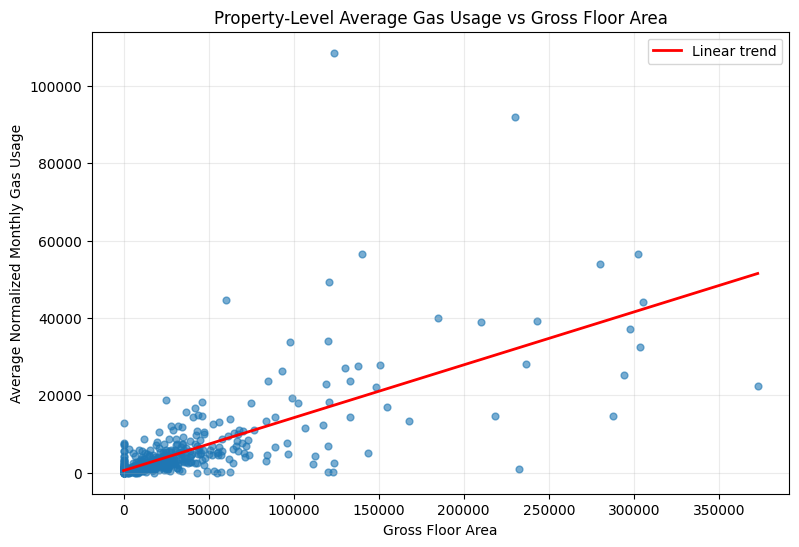

In [5]:
property_scatter_df = (
    df_filtered.groupby("property_id", as_index=False)
    .agg(
        avg_normalized_monthly_usage=("normalized_monthly_usage", "mean"),
        gross_floor_area=("Gross Floor Area", "median"),
    )
)

plt.figure(figsize=(9, 6))
plt.scatter(
    property_scatter_df["gross_floor_area"],
    property_scatter_df["avg_normalized_monthly_usage"],
    alpha=0.6,
    s=24,
)

# Optional linear trend line for quick visual assessment
x = property_scatter_df["gross_floor_area"].to_numpy()
y = property_scatter_df["avg_normalized_monthly_usage"].to_numpy()
coef = np.polyfit(x, y, 1)
x_line = np.array([x.min(), x.max()])
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line, color="red", linewidth=2, label="Linear trend")

plt.xlabel("Gross Floor Area")
plt.ylabel("Average Normalized Monthly Gas Usage")
plt.title("Property-Level Average Gas Usage vs Gross Floor Area")
plt.grid(alpha=0.25)
plt.legend()

corr = property_scatter_df["gross_floor_area"].corr(
    property_scatter_df["avg_normalized_monthly_usage"]
)
print(f"Pearson correlation (area vs avg usage): {corr:.3f}")

plt.show()


## 6) Visual check by property type

Create separate scatter plots of **average monthly gas usage vs gross floor area** for each property type.
Each subplot represents one property category.


Property types found: 13


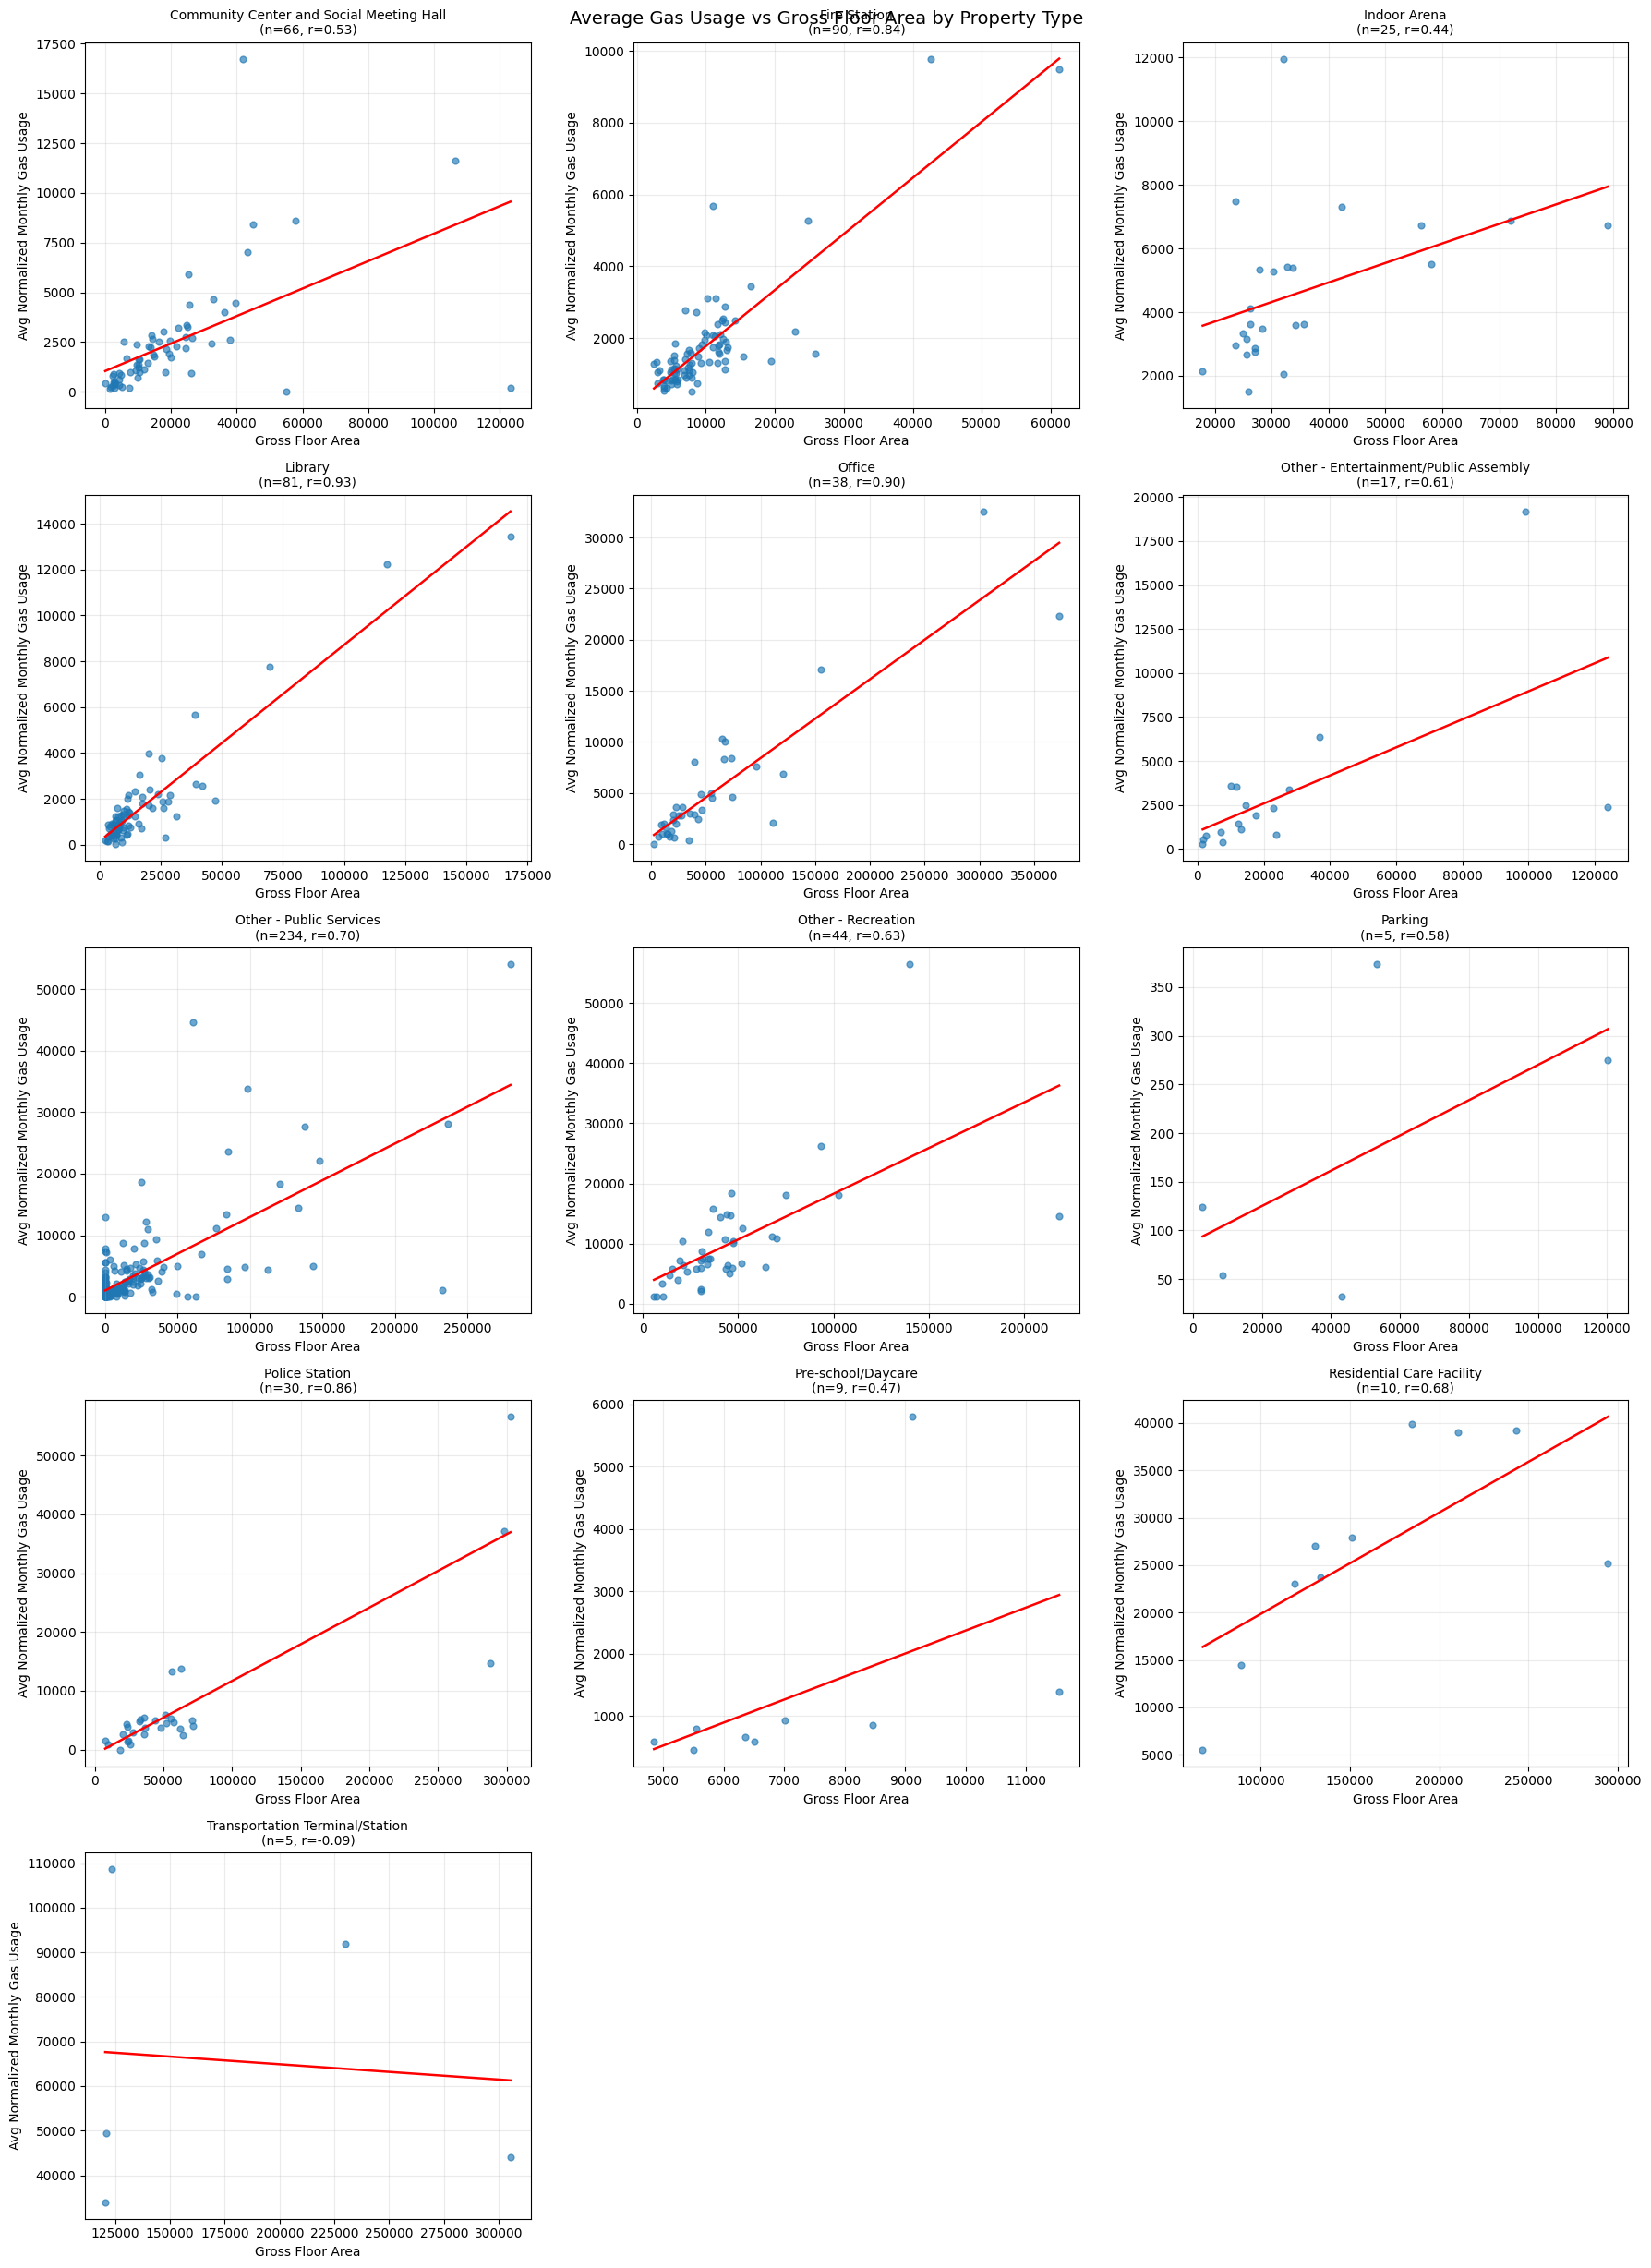

In [6]:
property_type_scatter_df = (
    df_filtered.groupby(["property_id", "Property Type - Self-Selected"], as_index=False)
    .agg(
        avg_normalized_monthly_usage=("normalized_monthly_usage", "mean"),
        gross_floor_area=("Gross Floor Area", "median"),
    )
)

property_types = sorted(property_type_scatter_df["Property Type - Self-Selected"].dropna().unique())
print(f"Property types found: {len(property_types)}")

n_cols = 3
n_rows = int(np.ceil(len(property_types) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, ptype in enumerate(property_types):
    ax = axes[i]
    subset = property_type_scatter_df[
        property_type_scatter_df["Property Type - Self-Selected"] == ptype
    ]

    ax.scatter(
        subset["gross_floor_area"],
        subset["avg_normalized_monthly_usage"],
        alpha=0.65,
        s=24,
    )

    # Draw trend line only when enough points exist
    if len(subset) >= 2:
        x = subset["gross_floor_area"].to_numpy()
        y = subset["avg_normalized_monthly_usage"].to_numpy()
        coef = np.polyfit(x, y, 1)
        x_line = np.array([x.min(), x.max()])
        y_line = coef[0] * x_line + coef[1]
        ax.plot(x_line, y_line, color="red", linewidth=1.8)

        corr = subset["gross_floor_area"].corr(subset["avg_normalized_monthly_usage"])
        corr_text = f"r={corr:.2f}" if pd.notna(corr) else "r=NA"
    else:
        corr_text = "r=NA"

    ax.set_title(f"{ptype}\n(n={len(subset)}, {corr_text})", fontsize=10)
    ax.set_xlabel("Gross Floor Area")
    ax.set_ylabel("Avg Normalized Monthly Gas Usage")
    ax.grid(alpha=0.25)

# Hide unused subplot slots
for j in range(len(property_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Average Gas Usage vs Gross Floor Area by Property Type", fontsize=14)
plt.tight_layout()
plt.show()


## 7) Seasonal trend in average gas usage (all buildings)

Plot average normalized monthly gas usage by month across all buildings.


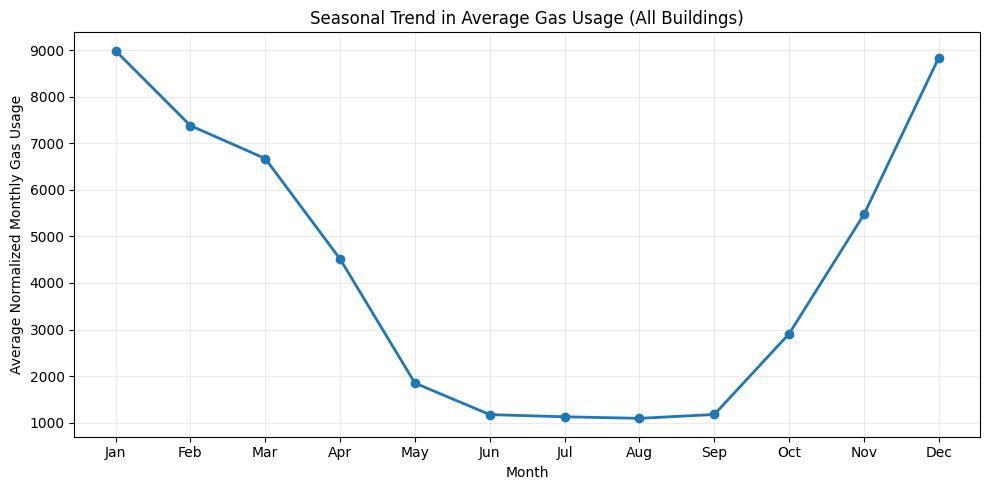

month
Jan    8988.652958
Feb    7380.107037
Mar    6671.821113
Apr    4514.690491
May    1849.935846
Jun    1173.059835
Jul    1126.392344
Aug    1092.905223
Sep    1175.514537
Oct    2909.824169
Nov    5472.637062
Dec    8842.900780
Name: normalized_monthly_usage, dtype: float64

In [7]:
seasonal_all = (
    df_filtered.groupby("month", observed=False)["normalized_monthly_usage"]
    .mean()
    .reindex(MONTH_ORDER)
)

plt.figure(figsize=(10, 5))
plt.plot(MONTH_ORDER, seasonal_all.values, marker="o", linewidth=2)
plt.title("Seasonal Trend in Average Gas Usage (All Buildings)")
plt.xlabel("Month")
plt.ylabel("Average Normalized Monthly Gas Usage")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

seasonal_all


## 8) Seasonal trend in average gas usage by property type

Create one seasonal line plot per property type to compare monthly usage patterns across building categories.


Property types found: 13


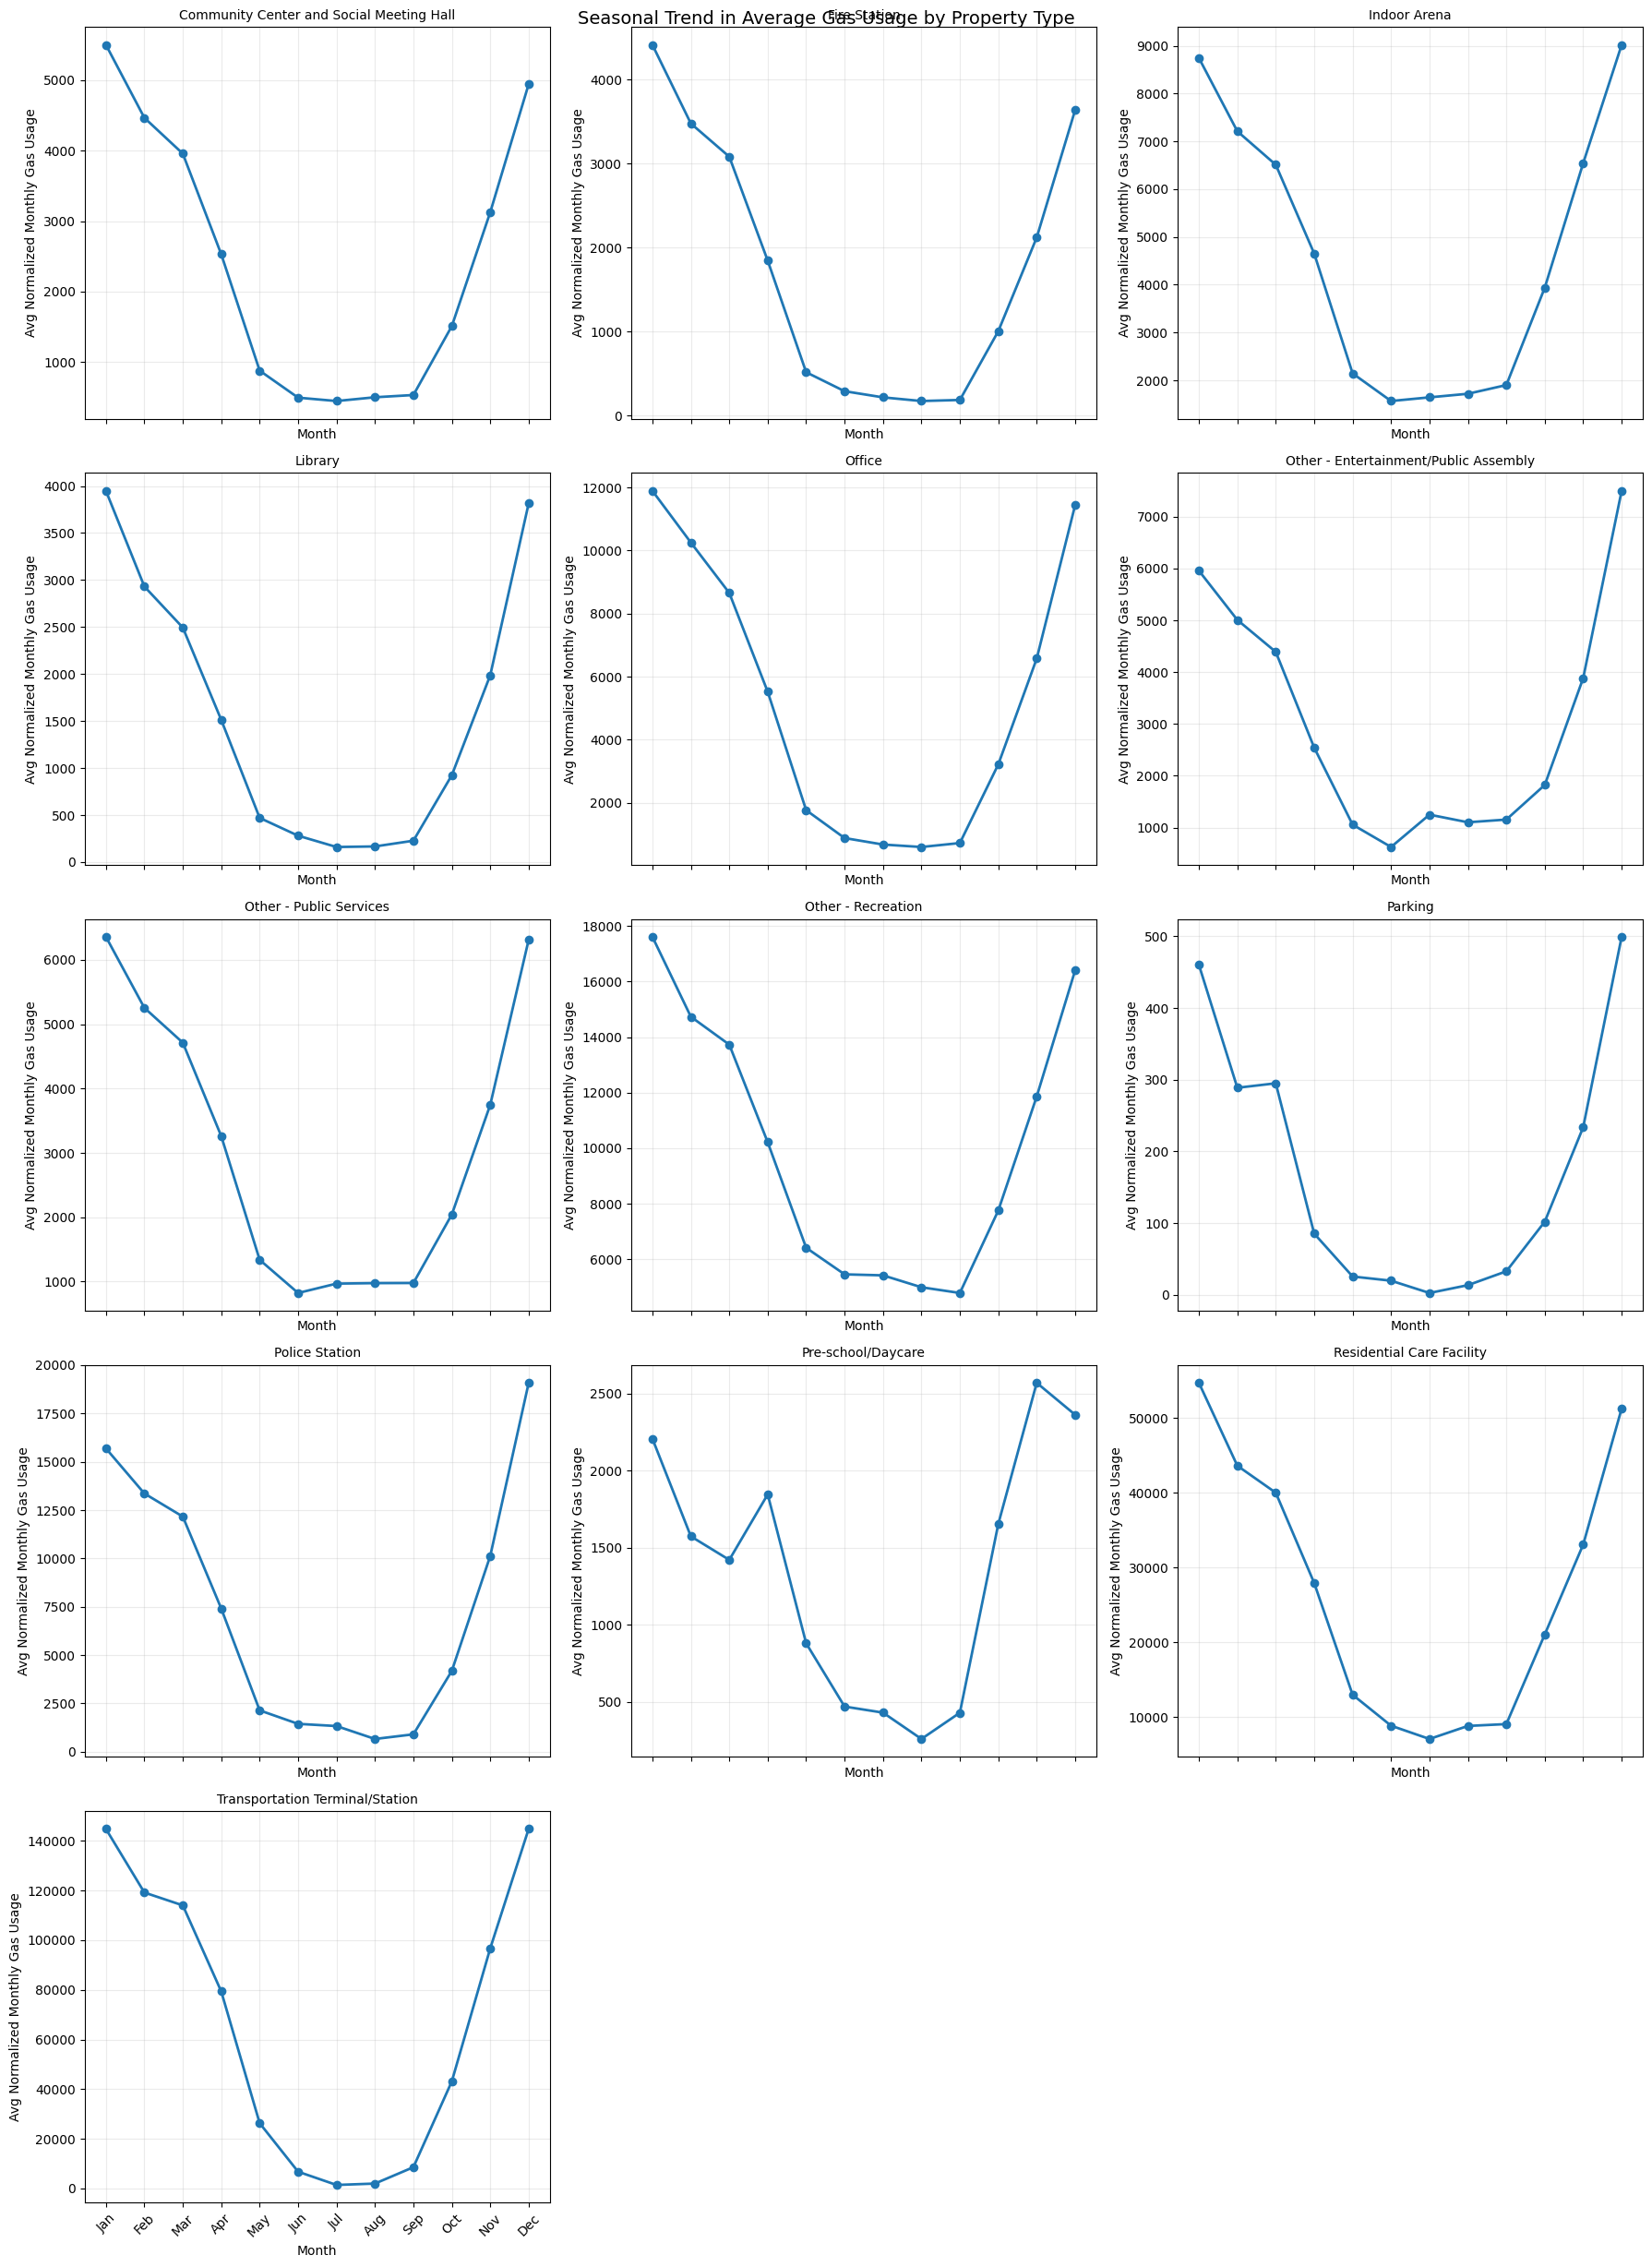

In [8]:
seasonal_by_type = (
    df_filtered.groupby(["Property Type - Self-Selected", "month"], observed=False)["normalized_monthly_usage"]
    .mean()
    .reset_index()
)

property_types = sorted(seasonal_by_type["Property Type - Self-Selected"].dropna().unique())
print(f"Property types found: {len(property_types)}")

n_cols = 3
n_rows = int(np.ceil(len(property_types) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), sharex=True, sharey=False)
axes = np.array(axes).reshape(-1)

for i, ptype in enumerate(property_types):
    ax = axes[i]
    subset = seasonal_by_type[
        seasonal_by_type["Property Type - Self-Selected"] == ptype
    ].copy()

    monthly_series = (
        subset.set_index("month")["normalized_monthly_usage"]
        .reindex(MONTH_ORDER)
    )

    ax.plot(MONTH_ORDER, monthly_series.values, marker="o", linewidth=2)
    ax.set_title(ptype, fontsize=10)
    ax.set_xlabel("Month")
    ax.set_ylabel("Avg Normalized Monthly Gas Usage")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25)

for j in range(len(property_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Seasonal Trend in Average Gas Usage by Property Type", fontsize=14)
plt.tight_layout()
plt.show()


## 9) Define predictors and target + create cyclical month and log transforms

In [9]:
df_filtered = df_filtered.copy()

df_filtered["month_num"] = pd.to_numeric(df_filtered["month_num"], errors="coerce")
df_filtered = df_filtered[df_filtered["month_num"].between(1, 12, inclusive="both")].copy()

df_filtered["month_sin"] = np.sin(2 * np.pi * df_filtered["month_num"] / 12.0)
df_filtered["month_cos"] = np.cos(2 * np.pi * df_filtered["month_num"] / 12.0)
df_filtered["log_gross_floor_area"] = np.log1p(df_filtered["Gross Floor Area"])
df_filtered["log_target"] = np.log1p(df_filtered["normalized_monthly_usage"])

categorical_features = ["Property Type - Self-Selected"]
numeric_features = ["month_sin", "month_cos", "log_gross_floor_area"]
feature_cols = categorical_features + numeric_features

target_col = "log_target"
id_col = "property_id"

X = df_filtered[feature_cols].copy()
y = df_filtered[target_col].copy()

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['Property Type - Self-Selected', 'month_sin', 'month_cos', 'log_gross_floor_area']
Target column: log_target


## 10) Build preprocessing + interaction features + linear regression model

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)


def build_feature_matrix_with_interactions(X_input, fit_preprocessor=False):
    base_matrix = preprocessor.fit_transform(X_input) if fit_preprocessor else preprocessor.transform(X_input)

    if hasattr(base_matrix, "toarray"):
        base_matrix = base_matrix.toarray()

    cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
    n_cat = len(cat_feature_names)

    cat_part = base_matrix[:, :n_cat]

    month_sin_idx = n_cat + numeric_features.index("month_sin")
    month_cos_idx = n_cat + numeric_features.index("month_cos")

    month_sin_vals = base_matrix[:, month_sin_idx][:, None]
    month_cos_vals = base_matrix[:, month_cos_idx][:, None]

    sin_interactions = cat_part * month_sin_vals
    cos_interactions = cat_part * month_cos_vals

    interaction_feature_names = np.concatenate(
        [
            [f"{name}__x__month_sin" for name in cat_feature_names],
            [f"{name}__x__month_cos" for name in cat_feature_names],
        ]
    )

    full_matrix = np.hstack([base_matrix, sin_interactions, cos_interactions])
    full_feature_names = np.concatenate([cat_feature_names, numeric_features, interaction_feature_names])

    return full_matrix, full_feature_names


model = LinearRegression()

model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 11) Train/test split by property (group-aware split, fixed seed)

Each property has monthly records. To avoid leakage, we split on `property_id` so one property appears in only one split.
A fixed random seed is used so all notebook variants share the same train/test sets and sampled row order.

In [11]:
# Property-level randomized split with a fixed seed for comparability across notebooks
SPLIT_SEED = 42

# Sort IDs before splitting so split membership is stable even if row order changes
unique_property_ids = (
    df_filtered[id_col]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

train_ids, test_ids = train_test_split(
    unique_property_ids,
    test_size=0.20,
    shuffle=True,
    random_state=SPLIT_SEED,
)

train_mask = df_filtered[id_col].isin(train_ids)
test_mask = df_filtered[id_col].isin(test_ids)

# Deterministic row sampling within each split while keeping X/y aligned
train_rng = np.random.default_rng(SPLIT_SEED)
test_rng = np.random.default_rng(SPLIT_SEED + 1)

train_idx = train_rng.permutation(df_filtered.index[train_mask].to_numpy())
test_idx = test_rng.permutation(df_filtered.index[test_mask].to_numpy())

X_train = X.loc[train_idx]
y_train = y.loc[train_idx]
X_test = X.loc[test_idx]
y_test = y.loc[test_idx]

print(f"Split seed: {SPLIT_SEED}")
print("Split mode: randomized with fixed seed (comparable across notebooks)")
print(f"Train properties: {len(train_ids):,}")
print(f"Test properties: {len(test_ids):,}")
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Split seed: 42
Split mode: randomized with fixed seed (comparable across notebooks)
Train properties: 523
Test properties: 131
Train rows: 6,276
Test rows: 1,572


## 12) Train model and generate predictions


In [12]:
X_train_model, model_feature_names = build_feature_matrix_with_interactions(
    X_train,
    fit_preprocessor=True,
)
X_test_model, _ = build_feature_matrix_with_interactions(
    X_test,
    fit_preprocessor=False,
)

print(f"Base + interaction feature count: {len(model_feature_names):,}")

model.fit(X_train_model, y_train)

y_train_pred_log = model.predict(X_train_model)
y_test_pred_log = model.predict(X_test_model)

# Convert predictions and targets back to original usage scale
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

Base + interaction feature count: 42


## 13) Evaluate performance (R2, MAE, RMSE)

In [13]:
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
    }

train_metrics = evaluate_regression(y_train_actual, y_train_pred)
test_metrics = evaluate_regression(y_test_actual, y_test_pred)
metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])

metrics_df

,R2,MAE,RMSE
Train,0.438360,2669.033921,9515.306293
Test,0.243567,1908.655401,7445.902087


## 14) Sample actual vs predicted values

In [14]:
test_results = pd.DataFrame({
    "property_id": df_filtered.loc[X_test.index, id_col].values,
    "month": df_filtered.loc[X_test.index, "month"].astype(str).values,
    "month_num": df_filtered.loc[X_test.index, "month_num"].astype(int).values,
    "actual_usage": y_test_actual.values,
    "predicted_usage": y_test_pred,
})

test_results["abs_error"] = (test_results["actual_usage"] - test_results["predicted_usage"]).abs()

test_results.head(12)

,property_id,month,month_num,actual_usage,predicted_usage,abs_error
0,34999351,Nov,11,2554.02,1635.750579,918.269421
1,34999782,Aug,8,0.00,28.274676,28.274676
2,35000371,Sep,9,92.19,46.175623,46.014377
3,34999291,Nov,11,646.85,494.532023,152.317977
4,34999683,May,5,36.00,39.980701,3.980701
5,34999363,Jun,6,64.38,131.626377,67.246377
6,34999402,Jan,1,2950.25,7847.135912,4896.885912
7,34999521,Jun,6,22.41,157.189129,134.779129
8,35000348,Mar,3,2158.79,1298.115647,860.674353
9,34999134,May,5,403.64,465.011613,61.371613
